In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px


# Load Data

In [121]:
df_Parcels = pd.read_csv("D:\Roya-assignment/Business Case Analyst - Data Sheet - Parcels Shipped.csv")
df_Account = pd.read_csv("D:\Roya-assignment/Business Case Analyst - Data Sheet - Account Creation.csv")
df_Customers = pd.read_csv("D:\Roya-assignment/Business Case Analyst - Data Sheet - Customers.csv")
df_Website = pd.read_csv("D:\Roya-assignment/Business Case Analyst - Data Sheet - Website traffic.csv")

# 1-Parcels Shipped

### Inspection

In [122]:

# basic info
df_Parcels.info()

# stats summary
df_Parcels.describe()

# missing values
print(df_Parcels.isna().sum())

df_Parcels.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       8 non-null      object
 1   Subscription  32 non-null     object
 2   SEO           32 non-null     object
 3   PPC           32 non-null     object
 4   Direct        32 non-null     object
 5   Other         32 non-null     object
 6   Total         32 non-null     object
dtypes: object(7)
memory usage: 1.9+ KB
Country         24
Subscription     0
SEO              0
PPC              0
Direct           0
Other            0
Total            0
dtype: int64


,Country,Subscription,SEO,PPC,Direct,Other,Total
0,Austria,1. Free,265,198,78,787,"1,328"
1,NaN,2. Lite,91,62,65,86,304
2,NaN,3. Growth,0,100,1,0,101
3,NaN,4. Premium,115,0,106,0,221
4,Belgium,1. Free,"1,141",839,"1,587",847,"4,414"


identifying the distinct values in each column of the dataframe. This assists me to learn the diversity of the data, the occurrence of categories within categorical columns, as well as any unexpected values, which may require cleaning or additional research.

In [123]:
# get unique values for each column
unique_values = {col: df_Parcels[col].unique() for col in df_Parcels.columns}
unique_values

{'Country': array(['Austria', nan, 'Belgium', 'Germany', 'Spain', 'France',
        'United Kingdom', 'Italy', 'Netherlands'], dtype=object),
 'Subscription': array(['1. Free', '2. Lite', '3. Growth', '4. Premium'], dtype=object),
 'SEO': array(['265', '91', '0', '115', '1,141', '140', '110', '268', '1,415',
        '378', '152', '344', '307', '7', '214', '319', '1,817', '430',
        '171', '438', '379', '30', '21', '497', '25', '17', '188', '494',
        '151', '108', '64', '1,248'], dtype=object),
 'PPC': array(['198', '62', '100', '0', '839', '138', '18', '462', '400', '553',
        '144', '141', '1,325', '256', '106', '954', '3,314', '268', '283',
        '184', '277', '194', '4', '502', '1,782', '464', '105', '615',
        '2,157', '20', '47'], dtype=object),
 'Direct': array(['78', '65', '1', '106', '1,587', '171', '173', '54', '1,276',
        '622', '79', '5,563', '2,172', '129', '373', '1,500', '2,868',
        '262', '3', '911', '119', '1,177', '97', '672', '103', '392',

### Cleaning

I removed the column 'Total' since there is a possibility that it can be redundant or it may not be required during analysis since in most cases sums can be derived through other columns, therefore having it would lead to duplication or confusion.

In [124]:
# drop the 'Total' column from the dataframe
df_Parcels = df_Parcels.drop(columns=['Total'])


The numbers in these columns are in the form of strings with commas (such as "2,159", "14,111"). This code purifies the formatting and transforms them to numeric values so that we can do some calculations or analysis on those.

In [125]:
# define columns to convert to numeric
cols = ['SEO', 'PPC', 'Direct', 'Other']

# loop through each column
for col in cols:
    # remove commas and convert strings to numbers; invalid parsing becomes NaN
    df_Parcels[col] = pd.to_numeric(df_Parcels[col].str.replace(',', ''), errors='coerce')

Some of the consecutive NaN values were observed in the column "Country" and using forward fill (ffill), each of the missing values was filled using the previous valid country.

In [126]:
# fill missing values in 'Country' column using forward fill
df_Parcels['Country'] = df_Parcels['Country'].ffill()

Each marketing channel, such as SEO, PPC, Direct and Other, was in a column in this dataframe. I melted the data to unpivot it and made it easier to analyze and visualize. This changed the individual columns into one channel column, the counts in a different column. Thus, a row now corresponds to the number of channels of a given country and type of subscription. It simplifies grouping, aggregating and plotting. And later, should I wish it, I could swivel it back to wide format to summaries or comparisons.

In [127]:
# unpivot the dataframe using melt
# 'Country' and 'Subscription' remain as id columns
# other columns become 'channel' with values in 'count'
df_Parcels = df_Parcels.melt(
    id_vars=['Country', 'Subscription'],
    var_name='channel',
    value_name='count')


df_Parcels.head()

,Country,Subscription,channel,count
0,Austria,1. Free,SEO,265
1,Austria,2. Lite,SEO,91
2,Austria,3. Growth,SEO,0
3,Austria,4. Premium,SEO,115
4,Belgium,1. Free,SEO,1141


To maintain the same naming convention, I renamed the column with the word Subscription to the word subscription in small letters, and I renamed the column with the word count to the word count_Parcels, to make it more descriptive.

In [128]:
# rename 'Subscription' column to lowercase 'subscription'
df_Parcels.rename(columns={'Subscription': 'subscription'}, inplace=True)

# rename 'count' column to 'count_Parcels' to make it more descriptive
df_Parcels.rename(columns={'count': 'count_Parcels'}, inplace=True)


subscription column was marked by a prefix of a number such as 1. Free' or '2. Premium'. I split the strings to eliminate the numbers and retained the subscription name only.

In [129]:
# remove the prefix number from 'subscription' column by splitting the string at '. ' and keeping the second part
df_Parcels['subscription'] = df_Parcels['subscription'].str.split('. ').str[1]
df_Parcels.head()

,Country,subscription,channel,count_Parcels
0,Austria,Free,SEO,265
1,Austria,Lite,SEO,91
2,Austria,Growth,SEO,0
3,Austria,Premium,SEO,115
4,Belgium,Free,SEO,1141


In [130]:
df_Parcels.to_excel("clean_Parcels.xlsx", index=False)

## 2-Account Creation

### Inspection

In [131]:
# show general info
df_Account.info()
# show statistical summary
df_Account.describe()
# count missing values in each column
print(df_Account.isna().sum())
df_Account.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9500 entries, 0 to 9499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          9500 non-null   object
 1   user_id       7440 non-null   object
 2   country       9500 non-null   object
 3   channel       9500 non-null   object
 4   subscription  9500 non-null   object
 5   event         9500 non-null   object
 6   count         9500 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 519.7+ KB
date               0
user_id         2060
country            0
channel            0
subscription       0
event              0
count              0
dtype: int64


,date,user_id,country,channel,subscription,event,count
0,2025-01-12,S0000001,Austria,SEO,Free,signup,1
1,2025-01-20,S0000002,Austria,SEO,Free,signup,1
2,2025-01-25,S0000003,Austria,SEO,Free,signup,1
3,2025-01-29,S0000004,Austria,SEO,Free,signup,1
4,2025-02-09,S0000005,Austria,SEO,Free,signup,1


In [132]:
# get unique values for each column in df_Account
unique_values = {col: df_Account[col].unique() for col in df_Account.columns}
unique_values

{'date': array(['2025-01-12', '2025-01-20', '2025-01-25', '2025-01-29',
        '2025-02-09', '2025-02-12', '2025-02-21', '2025-03-08',
        '2025-03-30', '2025-03-31', '2025-04-04', '2025-04-06',
        '2025-04-14', '2025-04-27', '2025-05-03', '2025-05-14',
        '2025-05-17', '2025-05-23', '2025-05-25', '2025-05-28',
        '2025-06-09', '2025-06-12', '2025-06-16', '2025-06-19',
        '2025-06-20', '2025-06-24', '2025-06-26', '2025-07-13',
        '2025-08-10', '2025-08-14', '2025-08-19', '2025-08-22',
        '2025-08-23', '2025-09-09', '2025-09-21', '2025-10-03',
        '2025-10-05', '2025-10-07', '2025-10-14', '2025-10-17',
        '2025-10-22', '2025-10-24', '2025-10-31', '2025-11-11',
        '2025-11-19', '2025-11-26', '2025-11-29', '2025-12-01',
        '2025-12-04', '2025-12-06', '2025-12-11', '2025-12-12',
        '2025-12-13', '2025-12-17', '2025-12-19', '2025-12-29',
        '2025-01-02', '2025-01-03', '2025-01-04', '2025-01-06',
        '2025-01-10', '2025-01-1

## Cleaning

I changed the date column to the format of the date to datetime to be able to deal with dates easily. I then filtered out any rows that were likely to be wrong or unwanted, which are in 2027 and restored the index to retain the dataframe.

In [133]:
# convert the 'date' column to datetime format
df_Account['date'] = pd.to_datetime(df_Account['date'])

# remove rows where the year is 2027 and reset the index
df_Account = df_Account[df_Account['date'].dt.year != 2027].reset_index(drop=True)

I realized that some of the user id values were not provided and filled them in. The former, I took the last remaining ID and of it, I extracted the number. Then I created new sequential IDs of all missing records of the format of S0000001, S0000002, et cetera, to keep everything consistent.

In [134]:
# get the last non-missing user_id
last_id = df_Account['user_id'].dropna().iloc[-1]

# extract the numeric part of the last user_id
start = int(last_id.replace('S', ''))

# create a mask for rows where user_id is missing
mask = df_Account['user_id'].isna()
n_missing = mask.sum()

# generate new sequential IDs for missing user_id entries
new_ids = range(start + 1, start + 1 + n_missing)
df_Account.loc[mask, 'user_id'] = [f"S{i:07d}" for i in new_ids]


In [135]:
df_Account.isna().sum()

date            0
user_id         0
country         0
channel         0
subscription    0
event           0
count           0
dtype: int64

In [136]:
# rename 'country' column to 'Country' for consistency
df_Account.rename(columns={'country': 'Country'}, inplace=True)

# rename 'count' column to 'count_Account' to make it descriptive
df_Account.rename(columns={'count': 'count_Account'}, inplace=True)

df_Account.head()

,date,user_id,Country,channel,subscription,event,count_Account
0,2025-01-12,S0000001,Austria,SEO,Free,signup,1
1,2025-01-20,S0000002,Austria,SEO,Free,signup,1
2,2025-01-25,S0000003,Austria,SEO,Free,signup,1
3,2025-01-29,S0000004,Austria,SEO,Free,signup,1
4,2025-02-09,S0000005,Austria,SEO,Free,signup,1


In [137]:
#sorting date
df_Account = df_Account.sort_values(by='date')
df_Account.head()

,date,user_id,Country,channel,subscription,event,count_Account
2807,2025-01-01,S0002808,Spain,PPC,Free,signup,1
3125,2025-01-01,S0003126,Spain,Direct,Free,signup,1
3124,2025-01-01,S0003125,Spain,Direct,Free,signup,1
2806,2025-01-01,S0002807,Spain,PPC,Free,signup,1
6011,2025-01-01,S0006012,United Kingdom,SEO,Free,signup,1


In [138]:
df_Account.to_excel("clean_Account.xlsx", index=False)

## 3-Customers

## Inspection

In [139]:
# show general info about the df_Customers dataframe
df_Customers.info()
# show statistical summary of numerical columns
df_Customers.describe()
# count missing values in each column
print(df_Customers.isna().sum())
df_Customers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       8 non-null      object
 1   Subscription  32 non-null     object
 2   SEO           32 non-null     int64 
 3   PPC           32 non-null     int64 
 4   Direct        32 non-null     int64 
 5   Other         32 non-null     int64 
 6   Total         32 non-null     object
dtypes: int64(4), object(3)
memory usage: 1.9+ KB
Country         24
Subscription     0
SEO              0
PPC              0
Direct           0
Other            0
Total            0
dtype: int64


,Country,Subscription,SEO,PPC,Direct,Other,Total
0,Austria,1. Free,31,21,30,56,138
1,NaN,2. Lite,5,12,6,8,31
2,NaN,3. Growth,0,3,3,0,6
3,NaN,4. Premium,2,0,2,0,4
4,Belgium,1. Free,17,126,53,134,330


In [140]:
# get unique values for each column
unique_values = {col: df_Customers[col].unique() for col in df_Customers.columns}
unique_values

{'Country': array(['Austria', nan, 'Belgium', 'Germany', 'Spain', 'France',
        'United Kingdom', 'Italy', 'Netherlands'], dtype=object),
 'Subscription': array(['1. Free', '2. Lite', '3. Growth', '4. Premium'], dtype=object),
 'SEO': array([ 31,   5,   0,   2,  17,   4, 124,  15,   3,  10, 111,   1, 227,
         65,  18,   6, 269,  11,  27], dtype=int64),
 'PPC': array([ 21,  12,   3,   0, 126,  13,   1,  96,   7,   2,   6, 100,   9,
        357,  11,  52,  10, 111, 182,   8,   4,  16], dtype=int64),
 'Direct': array([ 30,   6,   3,   2,  53,  18,   4, 256,  21,   5, 115, 212,  16,
         19, 266,  12,  28,   1,  48,  25,  22, 101], dtype=int64),
 'Other': array([ 56,   8,   0, 134,  13,   1,  78,  12,   5,   3, 101,   2,   4,
        676,  37,  36,  67, 321,  26], dtype=int64),
 'Total': array(['138', '31', '6', '4', '330', '46', '8', '554', '55', '15', '134',
        '524', '37', '25', '17', '1,526', '61', '10', '39', '154', '18',
        '20', '236', '45', '29', '873', '66',

### Cleaning

Some of the consecutive NaN values were observed in the column "Country" and using forward fill (ffill), each of the missing values was filled using the previous valid country.

In [141]:
# fill missing values in 'Country' column using forward fill
df_Customers['Country'] = df_Customers['Country'].ffill()

# drop the 'Total' column as it is redundant
df_Customers = df_Customers.drop(columns=['Total'])

Each marketing channel, such as SEO, PPC, Direct and Other, was in a column in this dataframe. I melted the data to unpivot it and made it easier to analyze and visualize. This changed the individual columns into one channel column, the counts in a different column. Thus, a row now corresponds to the number of channels of a given country and type of subscription. It simplifies grouping, aggregating and plotting. And later, should I wish it, I could swivel it back to wide format to summaries or comparisons.

In [142]:
# unpivot the dataframe from wide to long format
# 'Country' and 'Subscription' remain as identifier columns
# other columns become 'channel' with values in 'count'
df_Customers = df_Customers.melt(
    id_vars=['Country', 'Subscription'],
    var_name='channel',
    value_name='count')

df_Customers.head()

,Country,Subscription,channel,count
0,Austria,1. Free,SEO,31
1,Austria,2. Lite,SEO,5
2,Austria,3. Growth,SEO,0
3,Austria,4. Premium,SEO,2
4,Belgium,1. Free,SEO,17


In [143]:
# rename 'Subscription' column to lowercase
df_Customers.rename(columns={'Subscription': 'subscription'}, inplace=True)

# rename 'count' column to 'count_Customers' to make it descriptive
df_Customers.rename(columns={'count': 'count_Customers'}, inplace=True)

subscription column was marked by a prefix of a number such as 1. Free' or '2. Premium'. I split the strings to eliminate the numbers and retained the subscription name only.

In [144]:
df_Customers['subscription'] = df_Customers['subscription'].str.split('. ').str[1]
df_Customers.head()

,Country,subscription,channel,count_Customers
0,Austria,Free,SEO,31
1,Austria,Lite,SEO,5
2,Austria,Growth,SEO,0
3,Austria,Premium,SEO,2
4,Belgium,Free,SEO,17


In [145]:
df_Customers.to_excel("clean_Customers.xlsx", index=False)

## 4-Website traffic

### Inspection

In [146]:

# show general info 
df_Website.info()

# show statistical summary 
df_Website.describe()

# count missing values in each column
print(df_Website.isna().sum())

df_Website.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53265 entries, 0 to 53264
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      53265 non-null  object
 1   market    53265 non-null  object
 2   city      53265 non-null  object
 3   channel   53265 non-null  object
 4   sessions  53265 non-null  object
dtypes: object(5)
memory usage: 2.0+ MB
date        0
market      0
city        0
channel     0
sessions    0
dtype: int64


,date,market,city,channel,sessions
0,2025-01-01,Austria,Vienna,SEO,17
1,2025-01-01,Austria,Graz,SEO,10
2,2025-01-01,Austria,Linz,SEO,6
3,2025-01-01,Austria,Salzburg,SEO,5
4,2025-01-01,Austria,Innsbruck,SEO,8


In [147]:
# get unique values for each column
unique_values = {col: df_Website[col].unique() for col in df_Website.columns}
unique_values

{'date': array(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
        '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
        '2025-01-09', '2025-01-10', '2025-01-11', '2025-01-12',
        '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-16',
        '2025-01-17', '2025-01-18', '2025-01-19', '2025-01-20',
        '2025-01-21', '2025-01-22', '2025-01-23', '2025-01-24',
        '2025-01-25', '2025-01-26', '2025-01-27', '2025-01-28',
        '2025-01-29', '2025-01-30', '2025-01-31', '2025-02-01',
        '2025-02-02', '2025-02-03', '2025-02-04', '2025-02-05',
        '2025-02-06', '2025-02-07', '2025-02-08', '2025-02-09',
        '2025-02-10', '2025-02-11', '2025-02-12', '2025-02-13',
        '2025-02-14', '2025-02-15', '2025-02-16', '2025-02-17',
        '2025-02-18', '2025-02-19', '2025-02-20', '2025-02-21',
        '2025-02-22', '2025-02-23', '2025-02-24', '2025-02-25',
        '2025-02-26', '2025-02-27', '2025-02-28', '2025-03-01',
        '2025-03-02', '2025-03-0

### Cleaning

Checking the unique values, I identified certain errors like 7..0, 8..0, "error" and "SE0 "which I took care of in the following steps.

In [148]:
# convert 'sessions' column to numeric, coercing any non-numeric values to NaN
df_Website['sessions'] = pd.to_numeric(df_Website['sessions'], errors='coerce')

In order to manage the errors in the sessions column, I first plotted the data as a histogram to see how it was distributed. The skewness was +2.4 which is very skewed. I then turned the column into a numeric one, forcing any non-numeric numbers to NaN.

Due to the skew in distribution, I used the median instead of the mean to fill the missing values grouped by 'market', 'city' and 'channel' to reduce the effect of extreme values. A comparison between the statistical description (mean, median, standard deviation, min and max) of the pre- and post-this transformation revealed that the changes did not occur dramatically, which implied that this method was a suitable and a strong manner of managing the errors.

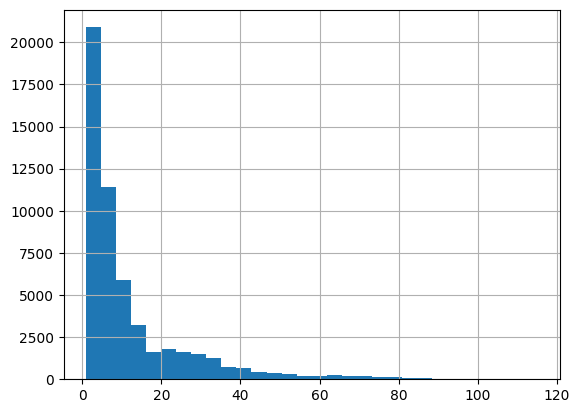

In [149]:
# plot a histogram of the 'sessions' column
df_Website['sessions'].hist(bins=30)
plt.show()

In [150]:
# calculate the skewness of the 'sessions' column
df_Website['sessions'].skew()

2.4100094524616247

In [151]:
# display statistical summary of 'sessions' before handling errors
print("Before:")
print(df_Website['sessions'].describe())

Before:
count    53262.000000
mean        11.940933
std         14.781048
min          1.000000
25%          3.000000
50%          6.000000
75%         14.000000
max        115.000000
Name: sessions, dtype: float64


In [152]:
# convert 'sessions' column to numeric
df_Website['sessions'] = pd.to_numeric(df_Website['sessions'], errors='coerce')

# fill NaN values with the median
df_Website['sessions'] = df_Website['sessions'].fillna(
    df_Website.groupby(['market', 'city', 'channel'])['sessions'].transform('median'))


In [153]:
# rename 'market' column to 'Country'
df_Website.rename(columns={'market': 'Country'}, inplace=True)

# fix the typo in the value name from 'SE0' to 'SEO'
df_Website.replace({'SE0': 'SEO'}, inplace=True)

In [154]:
df_Website.channel.unique()

array(['SEO', 'PPC', 'Direct', 'Other'], dtype=object)

In [155]:
# display statistical summary of 'sessions' after handling errors
print("After:")
print(df_Website['sessions'].describe())

After:
count    53264.000000
mean        11.940842
std         14.780786
min          1.000000
25%          3.000000
50%          6.000000
75%         14.000000
max        115.000000
Name: sessions, dtype: float64


In [156]:
df_Website.to_excel("clean_Website.xlsx", index=False)

# Insight

### Insight 1 Channel Quality

In [157]:
# aggregate total customers per channel
customers_channel = df_Customers.groupby('channel')['count_Customers'].sum().reset_index()

# aggregate total parcels per channel
parcels_channel = df_Parcels.groupby('channel')['count_Parcels'].sum().reset_index()

# merge customer and parcel totals by channel
quality_channel = customers_channel.merge(parcels_channel, on='channel')

# calculate parcels per customer for each channel
quality_channel['parcels_per_customer'] = (
    quality_channel['count_Parcels'] / quality_channel['count_Customers']
)

# sort channels by parcels per customer in descending order
quality_channel = quality_channel.sort_values(by='parcels_per_customer', ascending=False)

print(quality_channel)

  channel  count_Customers  count_Parcels  parcels_per_customer
0  Direct             1328          28080             21.144578
2     PPC             1173          16018             13.655584
3     SEO              992          11344             11.435484
1   Other             1615          16144              9.996285


The purpose of selecting this chart is that we can simultaneously visualize customer volume and customer quality. The bar chart indicates the average number of parcels per customer, which is a measure of customer engagement and value and the line chart is the total number of customers, which is a measure of channel volume.

With these two metrics in the same chart, it is easy to see which channels attract a high number of customers but have low engagement, and which channels attract a low number of customers but have high-value customers. This facilitates easier comparison of channel performance and comprehension of trade-off between the quantity and quality of a customer to make superior marketing and budget allocation choices.

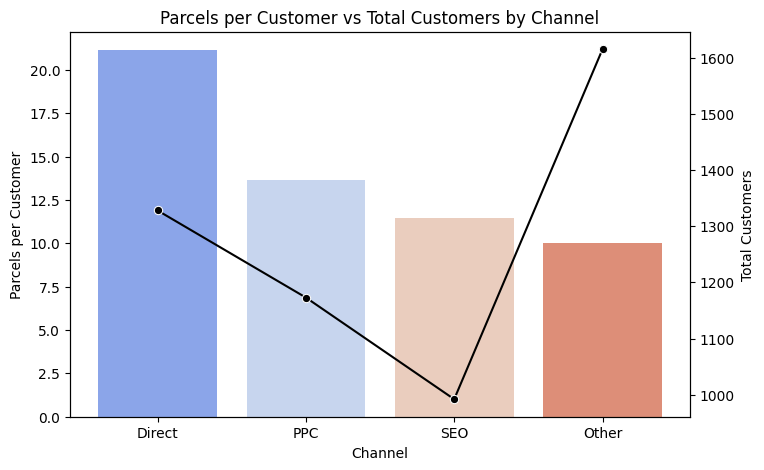

In [158]:

# create a figure and axes
fig, ax1 = plt.subplots(figsize=(8,5))

# create a second y-axis
ax2 = ax1.twinx()

# plot parcels per customer as a bar plot on the first y-axis
sns.barplot(data=quality_channel, x='channel', y='parcels_per_customer', ax=ax1, palette='coolwarm')

# plot total customers as a line plot on the second y-axis
sns.lineplot(data=quality_channel, x='channel', y='count_Customers', ax=ax2, marker='o', color='black')

# set labels and title
ax1.set_ylabel('Parcels per Customer')
ax2.set_ylabel('Total Customers')
ax1.set_xlabel('Channel')
plt.title('Parcels per Customer vs Total Customers by Channel')

plt.show()

What I found

The analysis reveals that there exist distinct customer quality variations in the marketing channels in terms of the number of parcels per customer. Direct channel is the one with the largest ratio of parcels-per-customer (21.14), implying that customers of this channel ship average way more parcels than the customers of other channels. The performance is not great in PPC and SEO channels, as the 13.66 and 11.44 parcels per customer are moderate. The Other channel is the most populated in terms of customers (1,615), and the least populated in terms of the parcel-per-customer ratio (9.99), which means that, even though more customers are attracted, they are not as active in this channel. On the whole, Direct creates the highest-value clients, whereas Other creates the highest volume but less-value clients.

 Why it matters

This understanding is critical since it reveals that the customer base does not significantly dictate the worth of the business. Customer quality is a better measure of revenue and profitability and can be expressed in terms of activity level and number of parcels shipped to the customer. Direct may be considered a more valuable channel than one that attracts a high number of less active customers. This assists the business in spending the marketing budget in a better manner and not necessarily on acquiring the customers but also on acquiring the high value customers.

What I would investigate next.

Had the data been more, I would explore the reasons why the Direct customers are more active and create more parcels. As an illustration, I would examine the case of Direct customers such as returning customers, business customers or clients through brand awareness. The comparison of the customer acquisition cost of each channel would also be made by me with the aim of analyzing which channel is the most profitable rather than the one that produces the highest number of customers. Besides, I would examine customer lifetime value (LTV) by channel to appreciate customer value and retention in the long term.

### Insight 2 Funnel Drop off

In [159]:
# aggregate total sessions per channel
sessions_channel = df_Website.groupby('channel')['sessions'].sum().reset_index()

# aggregate total accounts per channel
accounts_channel = df_Account.groupby('channel')['count_Account'].sum().reset_index()

# aggregate total customers per channel
customers_channel = df_Customers.groupby('channel')['count_Customers'].sum().reset_index()

# merge all metrics into a single dataframe
funnel = sessions_channel.merge(accounts_channel, on='channel')
funnel = funnel.merge(customers_channel, on='channel')

# calculate funnel conversion metrics
funnel['traffic_to_account'] = funnel['count_Account'] / funnel['sessions']
funnel['account_to_customer'] = funnel['count_Customers'] / funnel['count_Account']
funnel['traffic_to_customer'] = funnel['count_Customers'] / funnel['sessions']

# identify channels with high and low conversion efficiency
high_dropoff = funnel.sort_values(by='traffic_to_customer', ascending=False)
low_dropoff = funnel.sort_values(by='traffic_to_customer')


print("High Drop-off Channels:\n", high_dropoff)
print("\nLow Drop-off Channels:\n", low_dropoff)

High Drop-off Channels:
   channel  sessions  count_Account  count_Customers  traffic_to_account  \
1   Other   34948.0           3410             1615            0.097574   
0  Direct   85395.0           2408             1328            0.028198   
2     PPC  103168.0           2191             1173            0.021237   
3     SEO  412506.0           1488              992            0.003607   

   account_to_customer  traffic_to_customer  
1             0.473607             0.046212  
0             0.551495             0.015551  
2             0.535372             0.011370  
3             0.666667             0.002405  

Low Drop-off Channels:
   channel  sessions  count_Account  count_Customers  traffic_to_account  \
3     SEO  412506.0           1488              992            0.003607   
2     PPC  103168.0           2191             1173            0.021237   
0  Direct   85395.0           2408             1328            0.028198   
1   Other   34948.0           3410          

This chart is the most intuitive in order to visualize the movement of traffic through several stages: sessions - accounts - customers. Each of the stages is denoted as a layer becoming smaller at the top to the bottom indicating the location where visitors are shaken off by the funnel.

The reason why i selected this chart is that it graphically shows drop-off points at every stage, and it is at a glance that which channels lose visitors and which easily turns traffic into customers. It is ideal to demonstrate how the users move through the funnel and how the various channels perform in one easy-to-understand display.

In [160]:
# define the stages of the funnel
stages = ['Sessions', 'Accounts', 'Customers']

# get the list of channels
channels = funnel['channel'].tolist()

# create a funnel chart for each channel
for channel in channels:
    fig = go.Figure(go.Funnel(
        y=stages,
        x=funnel.loc[funnel['channel']==channel, ['sessions', 'count_Account', 'count_Customers']].values.flatten(),
        textinfo="value+percent initial"
    ))
    fig.update_layout(title_text=f'Funnel Conversion for {channel} Channel')
    fig.show()

This chart will indicate the efficiency of each channel used in marketing in converting the number of visitors to accounts, and further to customers. Each channel has three conversion rates, which include traffic-to- account, account-to-customer and total traffic-to-customer.

I adopted this chart since the three stages are arranged in the chart in such a way that one can easily compare channels by just looking at the chart. It shows explicitly where the visitors are lost throughout the funnel, and where they are lost and produce high quality and converting traffic. It displays several stages simultaneously, which gives a clear picture of efficiency of the channel and contributes to making marketing optimization decisions.


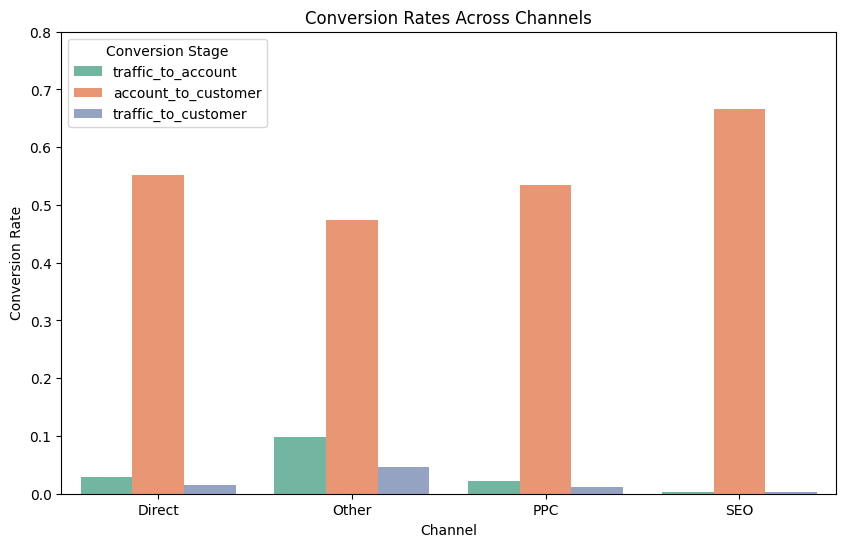

In [161]:
# reshape funnel metrics for plotting
funnel_melted = funnel.melt(
    id_vars='channel', 
    value_vars=['traffic_to_account', 'account_to_customer', 'traffic_to_customer'], 
    var_name='Conversion Stage', 
    value_name='Rate'
)

# set figure size
plt.figure(figsize=(10,6))

# create a bar plot for conversion rates by channel and stage
sns.barplot(data=funnel_melted, x='channel', y='Rate', hue='Conversion Stage', palette='Set2')

# add title and axis labels
plt.title('Conversion Rates Across Channels')
plt.ylabel('Conversion Rate')
plt.xlabel('Channel')

# adjust y-axis limit for better visualization
plt.ylim(0, max(funnel_melted['Rate'])*1.2)

plt.show()

what I found:

In the analysis of the marketing funnel across channels i have found that there is a obvious disparity between the channel efficiency of turning traffic into customers. The SEO channel generates the greatest number of traffic comprising 412, 504 sessions but only 1,488 accounts and 992 customers are produced, with a traffic to customer ratio of 0.24 only. This shows that SEO is a high drop-off channel, i.e. the majority of its visitors are not turned into paying customers. Conversely, Other channel is relatively low in terms of traffic, 34,948 sessions, however, it converts 1,615 customers, thus a traffic-to-customer ratio of 4.62, is a low drop-off channel. Direct and PPC channels are somewhere in between these extremes, and moderate traffic and conversion rates. This is a clear indication that high traffic does not necessarily translate into high-quality or high-value customers and that there are channels that are much more effective in getting the user through the funnel.

why it matters:

This is important since i am able to determine which channels are effective in driving customers and which are not in the process. The channels with high levels of drop-offs such as SEO might be getting a high number of visitors but they are not converting meaning that they are wasting their marketing budget or they are targeting the wrong people. On the other hand, low drop-off channels such as Other are offering better ROI(Return On Investment) and quality traffic, although at low volume. This allows us to gain actionable knowledge of where to focus campaigns, the landing pages, and how to invest in marketing to maximize the efficiency of customer acquisition by determining high and low drop-off channels.

what I would investigate next :

As i get more data, i may explore the behavior of the users on the high drop-off channels, including SEO by examining the bouncing rate, the time spent, the click patterns, and the landing page statistics. i might also be able to discuss campaign targeting, keywords, and ad content to know why traffic is not working. Acknowledging visitors based on their groups of demographics, device or location may help identify high-converting subgroups that are being overlooked. Also, by monitoring these funnel measures over a period of time, we would find out whether the optimizations in high drop-off channels help decrease the losses and increase the ROI, and transform previously poorly-performing channels into more effective sources of customer acquisition.

### Insight 3 Market Opportunity

In [162]:
# Group by country
country_customers = df_Customers.groupby('Country')['count_Customers'].sum().reset_index()
country_parcels = df_Parcels.groupby('Country')['count_Parcels'].sum().reset_index()
country_sessions = df_Website.groupby('Country')['sessions'].sum().reset_index()

# Merge datasets
country_funnel = country_customers.merge(country_parcels, on='Country')
country_funnel = country_funnel.merge(country_sessions, on='Country')

# Metrics
country_funnel['parcels_per_customer'] = country_funnel['count_Parcels'] / country_funnel['count_Customers']
country_funnel['traffic_to_customer'] = country_funnel['count_Customers'] / country_funnel['sessions']

# Sort by conversion or parcels per customer
country_funnel_sorted = country_funnel.sort_values(by='traffic_to_customer', ascending=False)

print(country_funnel_sorted)

          Country  count_Customers  count_Parcels  sessions  \
2          France             1636          12756  102999.0   
1         Belgium              392           6150   30802.0   
5     Netherlands             1013          19617  110695.0   
3         Germany              758          11781  101647.0   
6           Spain              603           8230  100785.0   
0         Austria              179           1954   29987.0   
7  United Kingdom              202           5116   43345.0   
4           Italy              325           5982  115757.0   

   parcels_per_customer  traffic_to_customer  
2              7.797066             0.015884  
1             15.688776             0.012726  
5             19.365252             0.009151  
3             15.542216             0.007457  
6             13.648425             0.005983  
0             10.916201             0.005969  
7             25.326733             0.004660  
4             18.406154             0.002808  


The reason behind using this scatter plot is that it is a good visualization tool that allows one to see customer value as well as funnel efficiency across different countries in one plot. The rate of traffic-to-customer conversion is plotted with the x-axis; the parcels per customer with the y-axis; and the bubble size with the number of customers. With this combination, we can easily tell high-value, high-conversion countries and make trade-offs between volume and efficiency, and make marketing and resource allocation decisions based on the data.

In [163]:

# Scatter plot: country performance

# X-axis: Traffic-to-customer conversion (efficiency of converting visitors)
# Y-axis: Parcels per customer (customer engagement/value)
# Size: Number of customers (shows volume)
# Color: Country


fig = px.scatter(
    country_funnel_sorted,
    x='traffic_to_customer',
    y='parcels_per_customer',
    size='count_Customers',
    color='Country',
    hover_name='Country',
    size_max=60,
    title='Country-Level Customer Value vs Funnel Efficiency')


fig.show()

What I found

When comparing the customer activity of various countries, one can observe some unique tendencies both in terms of the quality of the customers and their conversion. France has the largest number of customers, 1,636, but the average number of parcels per customer is average, 7.8, and traffic-to-customer conversion is 1.59%. However, in the United Kingdom the number of customers is much less (only 202) yet these customers are very active, they send an average of 25.33 parcels per customer, a sign of a high-value, yet smaller market. The Netherlands is a middle way and it has 1,013 customers with a send parcel of 19.37 and a conversion of 0.92, has a medium-size, high-value market. Relatively low customer numbers and lower conversion rate have been recorded in other countries like Italy and Austria. On the whole, it shows that certain countries, such as France and the Netherlands, can provide a high level of customers and a high level of revenue potential, and countries such as the UK are where the customers are of high value but the total market size is rather low.

Why it matters

This is important as it guides the marketing investment choices in that it reveals where the efforts will most probably create value. Premium campaigns should be done in high-value countries, including the UK and the Netherlands, to make the most out of the revenue per customer. Large-volume markets such as France provide the opportunity to multiply the total revenue, although the average customer price is average. Conversely, those countries who have low volume and low conversion can either need strategic funnel optimization to be able to increase efficiency or be more conservative in marketing expenditure. Knowing these trends would aid in prioritizing resources in an effective way balancing the number and quality of customers across markets.

What I would investigate next.

I would also look into customer segmentation based on the type of subscription in each country as to which plans are making the most number of parcels. I would also examine the sources of traffic and campaigns on a country basis to know why conversion is high or you are getting extremely high value customers. The analysis of customer lifetime value (LTV) by country would allow seeing a more long-term outlook on the potential of the market, as opposed to basing it only on the number of parcels. Lastly, local marketing can be further narrowed to the city-level or demographic variables, thus allowing a more focused and efficient campaign in that particular market.



### Insight 4 Customer Value by Subscription

In [164]:
# Group by subscription
subscription_customers = df_Customers.groupby('subscription')['count_Customers'].sum().reset_index()
subscription_parcels = df_Parcels.groupby('subscription')['count_Parcels'].sum().reset_index()

# Merge datasets
subscription_quality = subscription_customers.merge(subscription_parcels, on='subscription')

# Parcels per customer
subscription_quality['parcels_per_customer'] = subscription_quality['count_Parcels'] / subscription_quality['count_Customers']

# Sort by parcels per customer
subscription_quality = subscription_quality.sort_values(by='parcels_per_customer', ascending=False)

print(subscription_quality)

  subscription  count_Customers  count_Parcels  parcels_per_customer
3      Premium              315          19257             61.133333
1       Growth               99           3175             32.070707
2         Lite              359           6787             18.905292
0         Free             4335          42367              9.773241


The reason to use this combined chart is that it captures the two customer values and customer volumes together in the same chart. The bar chart shows the number of parcels sold per customer that measures customer interest and value, and the line chart is the total number of customers per type of subscription that is the measure of popularity. Using both of these measures together, I can discover popular but low-value and fewer customers but high-value subscriptions. This assists the business to know the most valuable subscription plans as well as the most creating customer subscription plans.

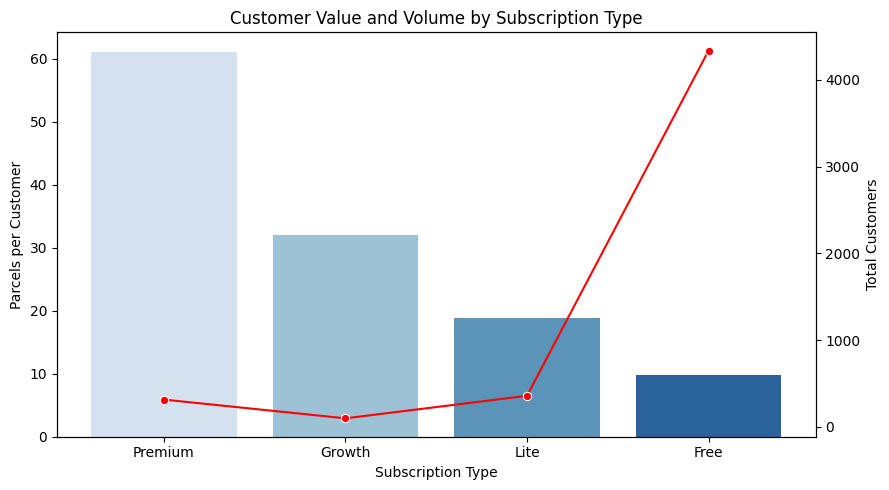

In [165]:
subscription_quality = subscription_quality.sort_values(by='parcels_per_customer', ascending=False)

fig, ax1 = plt.subplots(figsize=(9,5))

# Bar chart: Parcels per customer
sns.barplot(
    data=subscription_quality,
    x='subscription',
    y='parcels_per_customer',
    ax=ax1,
    palette='Blues'
)

ax1.set_ylabel('Parcels per Customer')
ax1.set_xlabel('Subscription Type')
ax1.set_title('Customer Value and Volume by Subscription Type')

# Line chart: Number of customers
ax2 = ax1.twinx()
sns.lineplot(
    data=subscription_quality,
    x='subscription',
    y='count_Customers',
    ax=ax2,
    marker='o',
    color='red'
)

ax2.set_ylabel('Total Customers')

plt.tight_layout()
plt.show()

what I found:

The activity of customers in terms of their type of subscription, it is evident that Premium customers are the most active and valuable. They can only cover a minor fraction of the user base, and have 315 customers, but with 19,257 parcels, their average is 61.13 parcels per customer. Compared to this, Free users are far more numerous, 4,335, but their average is only 9.77 parcels/customer. There is Growth and Lite between, which have moderate amounts of parcels per customer. This proves that although few, Premium users cause proportionately high activity meaning a highly engaged and valuable group.

why it matters:

This understanding is significant as it brings to the fore the high-value segment of the business. A targeted emphasis on retaining Premium users and upgrading Free or Lite users can also generate considerably more revenue than just acquiring more Free or Lite users. The large number of parcels per customer means a high level of engagement and possible profitability, in other words, the most significant profit can be made when marketing and customer success activities are focused on Premium users.

what i would investigate next:

Having more data would be useful to analyze the churn and retention of the Premium customers so they could become active in the long-term since losing high-value users can have an extreme effect on the revenue. Also, knowing the potential of upsell between Free and Lite to Premium would lead to growth potential. The behavioral patterns in the Premium segment may be analyzed in detail to find out what actions or interactions result in high parcel volume, i.e. how many times a certain product is ordered, what product is preferred, or how sensitive a particular product or marketing campaign is. Lastly, a comparison of the marketing ROI of the various types of subscriptions would enable the business to streamline the acquisition and retention strategies to ensure the business invests its resources in the most lucrative segments.

### Insight 5 Trend Analysis of Accounts and Traffics over time

In [166]:
# convert 'date' columns to datetime format
df_Account['date'] = pd.to_datetime(df_Account['date'])
df_Website['date'] = pd.to_datetime(df_Website['date'])

# aggregate daily totals for accounts and sessions
daily_accounts = df_Account.groupby('date')['count_Account'].sum().reset_index()
daily_sessions = df_Website.groupby('date')['sessions'].sum().reset_index()

# merge daily metrics into a single dataframe
daily_trend = daily_accounts.merge(daily_sessions, on='date')

# calculate cumulative totals
daily_trend['cumulative_accounts'] = daily_trend['count_Account'].cumsum()
daily_trend['cumulative_sessions'] = daily_trend['sessions'].cumsum()

# sort by date descending and reset index
daily_trend = daily_trend.sort_values(by='date', ascending=False).reset_index(drop=True)

# display daily trend
print("Daily Trend")
print(daily_trend)

# extract month from date for monthly aggregation
df_Account['month'] = df_Account['date'].dt.to_period('M')
df_Website['month'] = df_Website['date'].dt.to_period('M')

# aggregate monthly totals for accounts and sessions
monthly_accounts = df_Account.groupby('month')['count_Account'].sum().reset_index()
monthly_sessions = df_Website.groupby('month')['sessions'].sum().reset_index()

# merge monthly metrics into a single dataframe
monthly_trend = monthly_accounts.merge(monthly_sessions, on='month')

# calculate cumulative totals
monthly_trend['cumulative_accounts'] = monthly_trend['count_Account'].cumsum()
monthly_trend['cumulative_sessions'] = monthly_trend['sessions'].cumsum()

# sort by month descending and reset index
monthly_trend = monthly_trend.sort_values(by='month', ascending=False).reset_index(drop=True)


print("\nMonthly Trend")
print(monthly_trend)

Daily Trend
          date  count_Account  sessions  cumulative_accounts  \
0   2025-12-31             39    2213.0                 9497   
1   2025-12-30             56    2170.0                 9458   
2   2025-12-29             47    2152.0                 9402   
3   2025-12-28             45    2188.0                 9355   
4   2025-12-27             40    2122.0                 9310   
..         ...            ...       ...                  ...   
360 2025-01-05             23    1738.0                  116   
361 2025-01-04             19    1698.0                   93   
362 2025-01-03             20    1676.0                   74   
363 2025-01-02             27    1671.0                   54   
364 2025-01-01             27    1727.0                   27   

     cumulative_sessions  
0               636017.0  
1               633804.0  
2               631634.0  
3               629482.0  
4               627294.0  
..                   ...  
360               8510.0  
361

This chart has been selected as it demonstrates clearly the way in which the conversion rate varies with time. Time-series data are best represented by a line chart where it is easy to determine trends, patterns and fluctuations in conversion performance. Conversion rate over time helps us identify the improvement/degradation of marketing efforts, web site performance, or user behavior. This can assist in tracking performance and taking data-based actions to optimize conversion tactics.

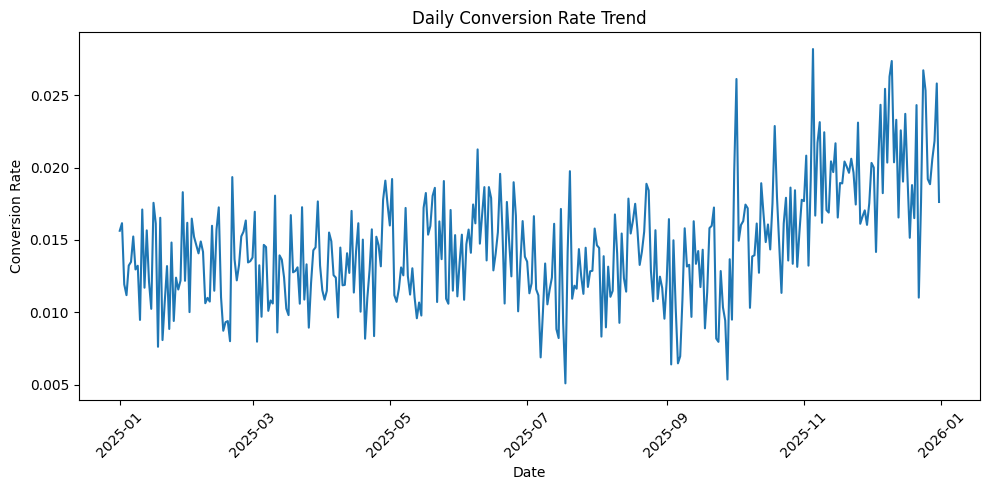

In [167]:
# Calculate daily conversion rate
# Conversion rate = number of accounts created / number of website sessions
daily_trend['conversion_rate'] = daily_trend['count_Account'] / daily_trend['sessions']

# Create a figure for the plot
plt.figure(figsize=(10,5))

# Plot conversion rate over time
# This shows how efficiently website traffic converts into accounts each day
plt.plot(daily_trend['date'], daily_trend['conversion_rate'])

# Add title and axis labels
plt.title('Daily Conversion Rate Trend')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')

# Rotate x-axis labels to make dates easier to read
plt.xticks(rotation=45)

# Adjust layout to prevent label cut-off
plt.tight_layout()

# Display the chart
plt.show()

what I found

Through the analysis of the daily trend and the monthly trend, I discovered that the traffic on the websites and the accounts that are being created is growing consistently with time showing a steady business growth. In January 2025, at the start of the year, the company had 52,654 sessions and 688 new accounts. This has grown to 67,159 sessions and 1,388 new account by December 2025, which demonstrates considerable expansion of the traffic and users acquisition. This growth trend is also supported by the cumulative trend where total sessions were 636,017 and total accounts were 9,497 at the end of the year. This appears to be growing stronger during the second half of the year especially after June, when; both the sessions and account sign-ups increased at a higher rate than during the initial half of the year. This means that the latter end of the year may have been better in terms of performance of the company, its marketing activities or brand recognition, or seasonal demand.
Explain why it matters

The point is significant in that it reveals that not only the business is drawing more visitors, but converting them into the users with time, which is the sign of the healthy business development. To illustrate, monthly growth of accounts doubled in January to 1,388 in December, representing a growth rate of about 2x monthly new users. On the same note, the number of sessions has risen by 52,654 to 67,159, indicating that traffic is also on the rise. This implies that marketing and acquisition strategies of the company are effective and attracting more users with time. Had the traffic gone up without a commensurate increase in accounts, it would reflect a conversion issue, but in this case both of these measures are increasing together, which is a good business indicator.

what I would investigate next 

Had more data been present, I would explore what marketing channels have been most contributive to growth during the period between January and December and whether a particular campaign or promotion resulted in increased traffic and account openings during the second half of the year. I would also examine the transformation of the 9,497 accounts opened in the year into paying customers since the growth of accounts does not necessarily translate into the growth of revenue. I would also see the trend of higher months compared to other months and whether this is a seasonal trend, campaign based, or long term business growth so that the company can repeat its winning strategies in future.

## Dimentions

In [168]:

clean_Account = pd.read_excel("D:\Roya-assignment/clean_Account.xlsx")
clean_Website = pd.read_excel("D:\Roya-assignment/clean_Website.xlsx")

In [169]:
dim_channel = clean_Website[['channel']].drop_duplicates().reset_index(drop=True)
dim_channel.head()

,channel
0,SEO
1,PPC
2,Direct
3,Other


In [170]:
dim_channel.to_excel("Dim_channel.xlsx", index=False)

In [171]:
dim_city = clean_Website[['city']].drop_duplicates().reset_index(drop=True)
dim_city.head()

,city
0,Vienna
1,Graz
2,Linz
3,Salzburg
4,Innsbruck


In [172]:
dim_Country = clean_Website[['Country']].drop_duplicates().reset_index(drop=True)
dim_Country.head()

,Country
0,Austria
1,Belgium
2,Germany
3,Spain
4,France


In [173]:
dim_Country.to_excel("Dim_Country.xlsx", index=False)

In [174]:
dim_city.to_excel("Dim_city.xlsx", index=False)

In [175]:
dim_subscription = clean_Account[['subscription']].drop_duplicates().reset_index(drop=True)
dim_subscription.head()

,subscription
0,Free
1,Lite
2,Premium
3,Growth


In [176]:
dim_subscription.to_excel("Dim_subscription.xlsx", index=False)

In [177]:
dim_userID = clean_Account[['user_id']].drop_duplicates().reset_index(drop=True)
dim_userID.head()

,user_id
0,S0002808
1,S0003126
2,S0003125
3,S0002807
4,S0006012


In [178]:
dim_userID.to_excel("dim_userID.xlsx", index=False)